In [1]:
# Google Colab / local setup
import os, sys, subprocess
from pathlib import Path
if "google.colab" in sys.modules:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
    CODE_ROOT = Path("/content/drive/MyDrive/msc project/code")
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-q", "--no-deps", "-e",
        str(CODE_ROOT), 'catboost==1.2.10', 'rapidfuzz==3.14.3',
    ])
else:
    CODE_ROOT = next(
        path for path in (Path.cwd(), *Path.cwd().parents)
        if (path / "pyproject.toml").exists()
    )
os.chdir(CODE_ROOT)
sys.path.insert(0, str(CODE_ROOT))
CODE = CODE_ROOT

# 03 — All-nine-model Logistic Regression stacking

## Methodology overview

This notebook tests whether a Logistic Regression meta-learner can combine all nine fixed model families from Notebook 02e. No model is removed. Separate stacks are built for No sentiment, DeBERTa and LLM, and for DZ55, DZ65 and DZ75; different dead-zone labels are never mixed.

The meta-learner receives `P(short)` and `P(long)` from every base model: 18 independent inputs, with `P(flat)` implied. It is a fixed `StandardScaler + L2 LogisticRegression(C=0.1, class_weight='balanced')`; no Optuna is used. The base models keep the 180-day history and 15-minute horizon.

Five 2024 BlockingTimeSeriesSplit OOF blocks train the first meta-model. January 2025 is predicted from 2024 OOF only; each completed H1 month is then added before predicting the next month. H1 evaluates 33 fixed confidence/TP/SL policies for each ensemble/DZ. Adequacy requires 50 trades, 15 long, 15 short and four positive months; candidates are ranked by adequacy, robust score, Sortino, net return and trades. H1 freezes one DZ and policy per sentiment/variant. Forward results are not opened in this notebook, and Q2-2026 is evaluated separately in Notebook 07.

The design follows Nti et al. for Logistic Regression stacking; Sebastião and Godinho supply the unanimity and net-cost controls; Derbentsev et al. motivate tree-family diversity; Lu et al. and Wang et al. motivate inclusion of deep temporal models.

### 1. Architecture and literature controls
The primary model is the all-nine stack; best single, equal soft vote and unanimity consensus are matched controls.

In [2]:
from pathlib import Path
import json
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option('display.max_rows', 50)
pd.set_option('display.max_columns', None)

CODE_ROOT = Path.cwd().resolve()
if CODE_ROOT.name == 'notebooks':
    CODE_ROOT = CODE_ROOT.parent
if str(CODE_ROOT) not in sys.path:
    sys.path.insert(0, str(CODE_ROOT))

from experiments.all_model_stacking import DEFAULT_ROOT, MODEL_LABELS, MODEL_NAMES, VARIANTS

ROOT = DEFAULT_ROOT
manifest = json.loads((ROOT / 'manifest.json').read_text(encoding='utf-8'))
per_dz = pd.read_parquet(ROOT / 'h1_selected_per_dz.parquet')
candidates = pd.read_parquet(ROOT / 'h1_selected_candidates.parquet')
coefficients = pd.read_parquet(ROOT / 'meta_coefficients.parquet')

assert len(MODEL_NAMES) == 9
assert len(per_dz) == 36 and len(candidates) == 12 and len(coefficients) == 486
assert manifest['lockbox_2026_q2_used'] is False
assert set(candidates['variant']) == set(VARIANTS)

In [3]:
from IPython.display import Markdown
architecture = pd.DataFrame({
    'Level': ['Base models', 'Meta inputs', 'Meta-learner', 'Controls'],
    'Definition': [
        ', '.join(MODEL_LABELS[name] for name in MODEL_NAMES),
        'P(short) and P(long) from each model — 18 features',
        'StandardScaler + L2 Logistic Regression, C=0.1, balanced',
        'Best single; equal soft vote; unanimity consensus',
    ],
})
display(Markdown('Method: The architecture uses all nine base families, their class probabilities and a causal Logistic Regression meta-learner.'))
display(architecture)
display(Markdown('Best-single, equal-vote and unanimity controls isolate the value of stacking.'))

Method: The architecture uses all nine base families, their class probabilities and a causal Logistic Regression meta-learner.

,Level,Definition
0,Base models,"Logistic Regression, Decision Tree, Random For..."
1,Meta inputs,P(short) and P(long) from each model — 18 feat...
2,Meta-learner,"StandardScaler + L2 Logistic Regression, C=0.1..."
3,Controls,Best single; equal soft vote; unanimity consensus


Best-single, equal-vote and unanimity controls isolate the value of stacking.

### 2. H1 policy selection for every DZ
Each row is selected from 33 policies using causal January-June 2025 predictions. Failed adequacy guards are shown, not removed.

In [4]:
from IPython.display import Markdown
h1_table = per_dz[[
    'Arm', 'variant', 'width_bps', 'selected_base_model', 'tau', 'tp_bps', 'sl_bps',
    'hold_minutes', 'trades', 'pooled_net', 'pooled_sortino', 'pooled_sharpe',
    'positive_segments', 'n_long', 'n_short'
]].copy()
h1_table['selected_base_model'] = h1_table['selected_base_model'].map(MODEL_LABELS).fillna('All nine')
h1_table['Pass guards'] = (
    (h1_table['trades'] >= 50) & (h1_table['n_long'] >= 15) &
    (h1_table['n_short'] >= 15) & (h1_table['positive_segments'] >= 4)
)
h1_table.columns = [
    'Sentiment', 'Variant', 'DZ', 'Model set', 'Threshold', 'TP', 'SL', 'Hold (min)',
    'Trades', 'Net return', 'Sortino', 'Sharpe', 'Positive months', 'Long', 'Short', 'Pass guards'
]
h1_table = h1_table.sort_values(['Sortino', 'Sharpe', 'Net return'], ascending=False, ignore_index=True)
display(Markdown('Method: Thirty-three policies are scored on causal H1 predictions separately for each Arm/variant/DZ.'))
display(h1_table.round(3))
display(Markdown('Rows failing trade or stability adequacy remain diagnostic.'))

Method: Thirty-three policies are scored on causal H1 predictions separately for each Arm/variant/DZ.

,Sentiment,Variant,DZ,Model set,Threshold,TP,SL,Hold (min),Trades,Net return,Sortino,Sharpe,Positive months,Long,Short,Pass guards
0,No sentiment,consensus,75,All nine,0.00,150,75,15,3,0.014,7.071,1.391,2,3,0,False
1,LLM,consensus,65,All nine,0.00,150,75,15,6,0.042,7.065,2.228,3,6,0,False
2,LLM,consensus,55,All nine,0.00,150,75,15,6,0.015,1.796,0.986,2,6,0,False
3,DeBERTa,best_single,55,CatBoost,0.70,200,100,15,113,0.042,1.343,0.848,4,70,43,True
4,No sentiment,best_single,55,LSTM,0.75,200,100,15,79,0.026,1.150,0.659,4,50,29,True
5,LLM,best_single,55,LSTM,0.70,200,100,15,272,0.031,0.797,0.491,3,118,154,False
6,DeBERTa,consensus,65,All nine,0.00,150,75,15,5,0.006,0.684,0.408,3,5,0,False
7,No sentiment,best_single,65,LSTM,0.75,200,100,15,136,0.007,0.253,0.158,4,97,39,True
8,DeBERTa,consensus,75,All nine,0.00,200,100,15,4,0.041,0.000,2.371,3,4,0,False
9,LLM,consensus,75,All nine,0.00,200,100,15,3,0.033,0.000,2.012,2,3,0,False


Rows failing trade or stability adequacy remain diagnostic.

### 3. H1-frozen candidates passed to Notebook 03a
One DZ and policy are frozen for each sentiment/variant using the same adequacy-first economic rule.

In [5]:
from IPython.display import Markdown
candidate_table = candidates[[
    'Arm', 'variant', 'width_bps', 'selected_base_model', 'tau', 'tp_bps', 'sl_bps',
    'hold_minutes', 'trades', 'pooled_net', 'pooled_sortino', 'pooled_sharpe',
    'positive_segments', 'n_long', 'n_short'
]].copy()
candidate_table['selected_base_model'] = candidate_table['selected_base_model'].map(MODEL_LABELS).fillna('All nine')
candidate_table['Pass guards'] = (
    (candidate_table['trades'] >= 50) & (candidate_table['n_long'] >= 15) &
    (candidate_table['n_short'] >= 15) & (candidate_table['positive_segments'] >= 4)
)
candidate_table.columns = [
    'Sentiment', 'Variant', 'DZ', 'Model set', 'Threshold', 'TP', 'SL', 'Hold (min)',
    'Trades', 'Net return', 'Sortino', 'Sharpe', 'Positive months', 'Long', 'Short', 'Pass guards'
]
candidate_table = candidate_table.sort_values(['Sortino', 'Sharpe', 'Net return'], ascending=False, ignore_index=True)
display(Markdown('Method: One width and policy per Arm/variant is frozen using the H1 adequacy-first rule.'))
display(candidate_table.round(3))
display(Markdown('Only these twelve candidates enter the matched forward comparison.'))

Method: One width and policy per Arm/variant is frozen using the H1 adequacy-first rule.

,Sentiment,Variant,DZ,Model set,Threshold,TP,SL,Hold (min),Trades,Net return,Sortino,Sharpe,Positive months,Long,Short,Pass guards
0,LLM,consensus,65,All nine,0.00,150,75,15,6,0.042,7.065,2.228,3,6,0,False
1,DeBERTa,best_single,55,CatBoost,0.70,200,100,15,113,0.042,1.343,0.848,4,70,43,True
2,No sentiment,best_single,55,LSTM,0.75,200,100,15,79,0.026,1.150,0.659,4,50,29,True
3,LLM,best_single,55,LSTM,0.70,200,100,15,272,0.031,0.797,0.491,3,118,154,False
4,DeBERTa,consensus,65,All nine,0.00,150,75,15,5,0.006,0.684,0.408,3,5,0,False
5,DeBERTa,soft_vote,55,All nine,0.55,150,75,15,195,-0.063,-1.618,-1.101,2,112,83,False
6,No sentiment,consensus,55,All nine,0.00,150,100,15,9,-0.034,-2.350,-2.170,1,9,0,False
7,LLM,stack,65,All nine,0.65,150,100,15,163,-0.093,-2.627,-1.873,2,49,114,False
8,DeBERTa,stack,55,All nine,0.60,200,100,15,253,-0.126,-2.859,-1.991,2,136,117,False
9,No sentiment,stack,55,All nine,0.60,150,100,15,140,-0.105,-3.012,-2.247,3,115,25,False


Only these twelve candidates enter the matched forward comparison.

### 4. Meta-learner coefficients
The heatmaps show the final pre-forward Logistic Regression weights for the H1-selected stack DZ in each sentiment arm.

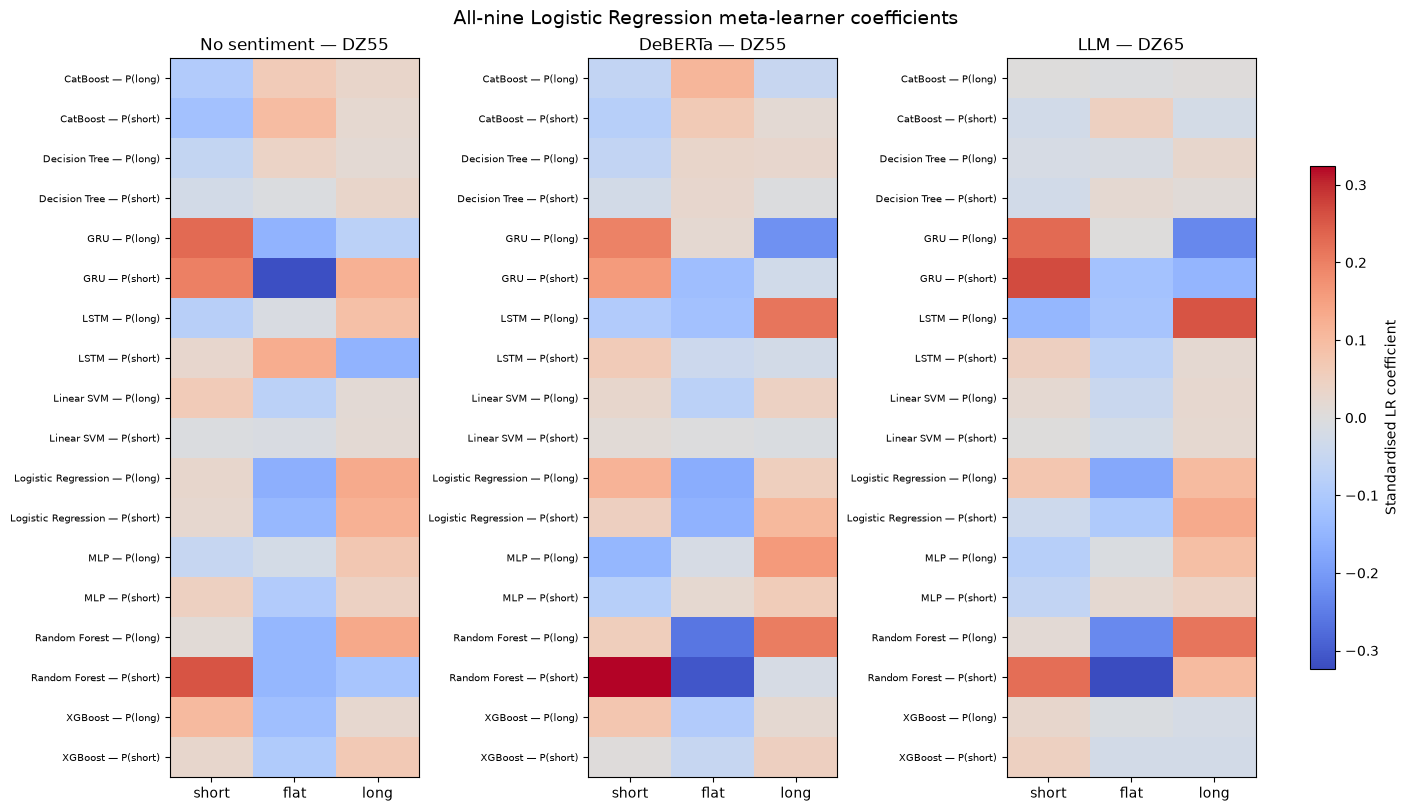

In [6]:
stack_choices = candidates.loc[candidates['variant'] == 'stack', ['sentiment_arm', 'Arm', 'width_bps']]
chosen = coefficients.merge(stack_choices, on=['sentiment_arm', 'Arm', 'width_bps'], how='inner')
panels = []
for arm, group in chosen.groupby('sentiment_arm', sort=False):
    matrix = group.pivot(index='feature', columns='class_label', values='coefficient').reindex(columns=['short', 'flat', 'long'])
    panels.append((group['Arm'].iloc[0], int(group['width_bps'].iloc[0]), matrix))
limit = max(abs(matrix.to_numpy()).max() for _, _, matrix in panels)
fig, axes = plt.subplots(1, 3, figsize=(14, 8), constrained_layout=True)
image = None
for axis, (label, width, matrix) in zip(axes, panels):
    image = axis.imshow(matrix, cmap='coolwarm', vmin=-limit, vmax=limit, aspect='auto')
    axis.set_title(f'{label} — DZ{width}')
    axis.set_xticks(range(3), ['short', 'flat', 'long'])
    axis.set_yticks(range(len(matrix)), matrix.index, fontsize=7)
fig.colorbar(image, ax=axes, shrink=0.7, label='Standardised LR coefficient')
fig.suptitle('All-nine Logistic Regression meta-learner coefficients', fontsize=14)
artifact_dir = CODE_ROOT / 'notebooks' / 'artifacts'
artifact_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(artifact_dir / '03_stacking_coefficients.png', dpi=180, bbox_inches='tight')
plt.show()

## Handoff to Notebook 03a

Notebook 03a may evaluate only the 12 rows in Table 3. It cannot change the base-model set, DZ, Logistic Regression, threshold, TP, SL or hold after seeing forward results. Guard failures remain visible rather than being silently excluded.